In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Check if PyPortfolioOpt is installed
try:
    from pypfopt import EfficientFrontier, risk_models, expected_returns
    print("PyPortfolioOpt available")
except ImportError:
    print("Need to install PyPortfolioOpt")

PyPortfolioOpt available


In [4]:
# Diversified ETF universe
tickers = ["SPY", "EFA", "AGG", "GLD", "VNQ"]

raw = yf.download(tickers, start="2010-01-01",
                   end="2024-01-01", auto_adjust=True)
prices = raw["Close"]
prices.columns = prices.columns.get_level_values(0)
prices = prices.dropna()

print(f"Assets loaded: {prices.columns.tolist()}")
print(f"Date range   : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Observations : {len(prices)}")

[*********************100%***********************]  5 of 5 completed

Assets loaded: ['AGG', 'EFA', 'GLD', 'SPY', 'VNQ']
Date range   : 2010-01-04 to 2023-12-29
Observations : 3522


INDIVIDUAL ASSET STATS
Asset      Ann Ret   Ann Vol   Sharpe
-------------------------------------------------------
SPY         13.65%    17.33%     0.67
EFA          6.77%    18.83%     0.25
AGG          2.46%     4.69%     0.10
GLD          5.18%    15.53%     0.20
VNQ         11.06%    21.01%     0.43


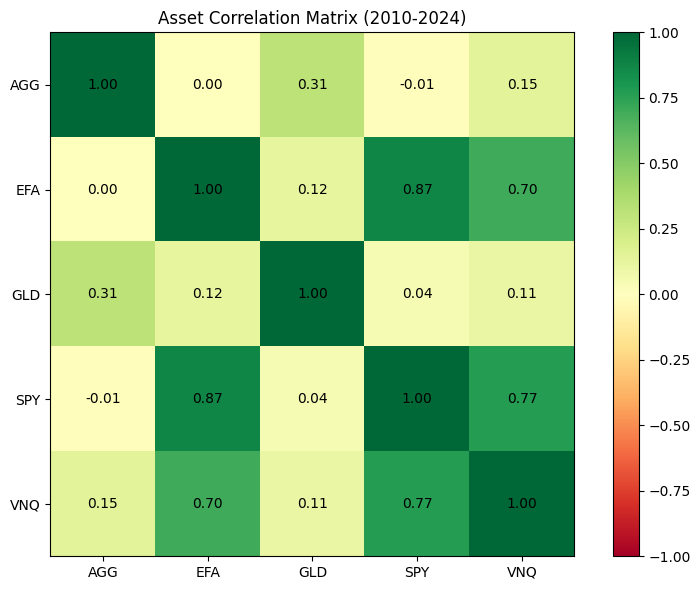

In [5]:
# Calculate returns and correlation matrix
returns = prices.pct_change().dropna()

corr = returns.corr()
ann_ret  = returns.mean() * 252
ann_vol  = returns.std()  * np.sqrt(252)
sharpe   = (ann_ret - 0.02) / ann_vol

print("INDIVIDUAL ASSET STATS")
print("=" * 55)
print(f"{'Asset':<8} {'Ann Ret':>9} {'Ann Vol':>9} {'Sharpe':>8}")
print("-" * 55)
for t in tickers:
    if t in ann_ret.index:
        print(f"{t:<8} {ann_ret[t]:>9.2%} {ann_vol[t]:>9.2%} {sharpe[t]:>8.2f}")
print("=" * 55)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=10,
                color='black')

ax.set_title('Asset Correlation Matrix (2010-2024)')
plt.tight_layout()
plt.show()

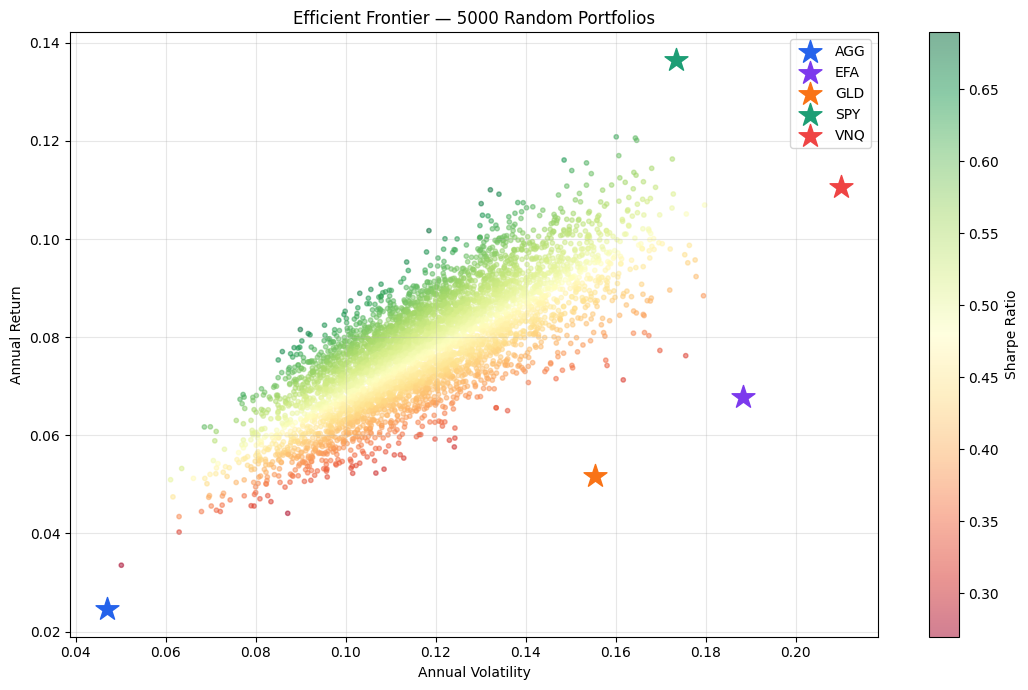

Best random Sharpe : 0.690
Best random return : 12.08%
Lowest random vol  : 5.01%


In [6]:
# Generate 5000 random portfolios
n_assets = len(tickers)
n_sims   = 5000

rand_returns = []
rand_vols    = []
rand_sharpes = []
rand_weights = []

for _ in range(n_sims):
    w = np.random.random(n_assets)
    w = w / w.sum()

    port_ret = np.sum(returns.mean() * w) * 252
    port_vol = np.sqrt(np.dot(w.T, np.dot(returns.cov() * 252, w)))
    port_sh  = (port_ret - 0.02) / port_vol

    rand_returns.append(port_ret)
    rand_vols.append(port_vol)
    rand_sharpes.append(port_sh)
    rand_weights.append(w)

rand_returns = np.array(rand_returns)
rand_vols    = np.array(rand_vols)
rand_sharpes = np.array(rand_sharpes)

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(rand_vols, rand_returns,
                     c=rand_sharpes, cmap='RdYlGn',
                     alpha=0.5, s=10)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Mark individual assets
colors = ['#2563eb','#7c3aed','#f97316','#1D9E75','#ef4444']
for i, t in enumerate(prices.columns):
    ax.scatter(ann_vol[t], ann_ret[t],
               marker='*', s=300, color=colors[i],
               zorder=5, label=t)

ax.set_title('Efficient Frontier — 5000 Random Portfolios')
ax.set_xlabel('Annual Volatility')
ax.set_ylabel('Annual Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best random Sharpe : {rand_sharpes.max():.3f}")
print(f"Best random return : {rand_returns.max():.2%}")
print(f"Lowest random vol  : {rand_vols.min():.2%}")

In [7]:
from pypfopt import EfficientFrontier, risk_models, expected_returns

# Calculate inputs
mu = expected_returns.mean_historical_return(prices)
S  = risk_models.sample_cov(prices)

# Portfolio 1: Equal Weight
ew_weights = {t: 1/len(prices.columns) for t in prices.columns}

# Portfolio 2: Maximum Sharpe
ef1 = EfficientFrontier(mu, S)
ms_weights = ef1.max_sharpe()
ms_weights = dict(ef1.clean_weights())
ms_perf    = ef1.portfolio_performance(verbose=False)

# Portfolio 3: Minimum Volatility
ef2 = EfficientFrontier(mu, S)
mv_weights = ef2.min_volatility()
mv_weights = dict(ef2.clean_weights())
mv_perf    = ef2.portfolio_performance(verbose=False)

# Print weights comparison
print(f"\n{'='*60}")
print(f"  PORTFOLIO WEIGHTS COMPARISON")
print(f"{'='*60}")
print(f"  {'Asset':<8} {'Equal Wt':>10} {'Max Sharpe':>12} {'Min Vol':>10}")
print(f"  {'-'*55}")
for t in prices.columns:
    print(f"  {t:<8} {ew_weights.get(t,0):>10.1%} "
          f"{ms_weights.get(t,0):>12.1%} "
          f"{mv_weights.get(t,0):>10.1%}")
print(f"{'='*60}")


  PORTFOLIO WEIGHTS COMPARISON
  Asset      Equal Wt   Max Sharpe    Min Vol
  -------------------------------------------------------
  AGG           20.0%        68.4%      93.0%
  EFA           20.0%         0.0%       0.5%
  GLD           20.0%         3.3%       0.0%
  SPY           20.0%        28.3%       6.5%
  VNQ           20.0%         0.0%       0.0%


[*********************100%***********************]  5 of 5 completed



  2022 STRESS TEST — OOS PERFORMANCE
  Portfolio             Ann Ret  Ann Vol  Sharpe    Max DD
  -------------------------------------------------------
  Equal Weight          -13.92%   15.33%   -1.04   -21.81%
  Max Sharpe            -13.91%   10.28%   -1.55   -17.38%
  Min Vol               -13.37%    8.15%   -1.89   -16.41%
  SPY Only              -17.85%   24.28%   -0.82   -24.47%


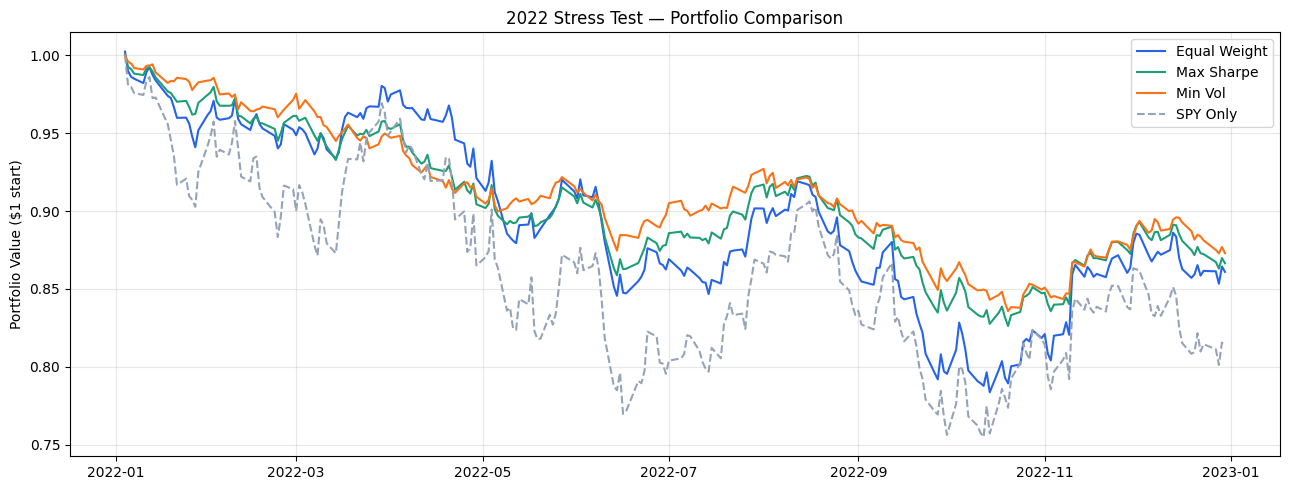

In [8]:
# Out-of-sample test: 2022 stress test
prices_oos = yf.download(tickers, start="2022-01-01",
                          end="2023-01-01", auto_adjust=True)
prices_oos = prices_oos["Close"]
prices_oos.columns = prices_oos.columns.get_level_values(0)
prices_oos = prices_oos.dropna()

returns_oos = prices_oos.pct_change().dropna()

def portfolio_returns(weights_dict, returns):
    """Calculate portfolio returns given weights dict."""
    w = pd.Series(weights_dict).reindex(returns.columns).fillna(0)
    w = w / w.sum()
    return (returns * w).sum(axis=1)

ew_ret  = portfolio_returns(ew_weights, returns_oos)
ms_ret  = portfolio_returns(ms_weights, returns_oos)
mv_ret  = portfolio_returns(mv_weights, returns_oos)
spy_ret = returns_oos["SPY"]

# Equity curves
ew_eq  = (1 + ew_ret).cumprod()
ms_eq  = (1 + ms_ret).cumprod()
mv_eq  = (1 + mv_ret).cumprod()
spy_eq = (1 + spy_ret).cumprod()

# Performance
def perf(r, name):
    ar = r.mean() * 252
    av = r.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av
    eq = (1 + r).cumprod()
    dd = ((eq - eq.cummax()) / eq.cummax()).min()
    print(f"  {name:<20} {ar:>8.2%} {av:>8.2%} {sh:>7.2f} {dd:>9.2%}")

print(f"\n{'='*60}")
print(f"  2022 STRESS TEST — OOS PERFORMANCE")
print(f"{'='*60}")
print(f"  {'Portfolio':<20} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*55}")
perf(ew_ret,  "Equal Weight")
perf(ms_ret,  "Max Sharpe")
perf(mv_ret,  "Min Vol")
perf(spy_ret, "SPY Only")
print(f"{'='*60}")

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ew_eq,  color='#2563eb', lw=1.5, label='Equal Weight')
ax.plot(ms_eq,  color='#1D9E75', lw=1.5, label='Max Sharpe')
ax.plot(mv_eq,  color='#f97316', lw=1.5, label='Min Vol')
ax.plot(spy_eq, color='#94a3b8', lw=1.5,
        linestyle='--', label='SPY Only')
ax.set_title('2022 Stress Test — Portfolio Comparison')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()